In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import ParameterGrid

import matplotlib.pyplot as plt
import seaborn as sns

from itertools import product
import joblib
from datetime import datetime
from pathlib import Path
from tqdm.auto import tqdm
import os, sys, logging

sys.path.append('../')
import src.forecasting.simulations      as sim
import src.fda.kde.estimators           as kde
import src.fda.transformations.lqdt     as lqdt
import src.forecasting.cross_validation as cv
import src.forecasting.pipelines        as fp
import src.forecasting.accuracy         as acc
import src.fda.utils                    as fdaUtils

In [2]:
EXECUTION_DATE : str = datetime.now().strftime('%Y%m%d')
# EXECUTION_DATE = '20260506'

LOG_PATH       : str = f'../logs/simulations/{EXECUTION_DATE}.log'
SIM_MAIN_PATH     : str = f'../data/interim/simulation/{EXECUTION_DATE}/'
SIMS_PATH      : str = f'../data/interim/simulation/{EXECUTION_DATE}/00_simulations/'
SIMS_LQD_PATH   : str = f'../data/interim/simulation/{EXECUTION_DATE}/01_lqds/'
KDES_PATH       : str = f'../data/interim/simulation/{EXECUTION_DATE}/02_kdes/'
KDES_LQDS_PATH   : str = f'../data/interim/simulation/{EXECUTION_DATE}/03_kde_lqds/'
CV_FCS_PATH     : str = f'../data/interim/simulation/{EXECUTION_DATE}/04_cv/'

Path(SIM_MAIN_PATH).mkdir(parents=True, exist_ok=True)
Path(SIMS_PATH).mkdir(parents=True, exist_ok=True)
Path(SIMS_LQD_PATH).mkdir(parents=True, exist_ok=True)
Path(KDES_PATH).mkdir(parents=True, exist_ok=True)
Path(KDES_LQDS_PATH).mkdir(parents=True, exist_ok=True)
Path(CV_FCS_PATH).mkdir(parents=True, exist_ok=True)

# GAS model

In [3]:
# Define scenarios
gas_params = {
    "scenario_1": {
        "Description": "Location-driven ($m_t$)",
        "alpha": np.diag([0.08, 0.01, 0.01]),
        "beta": np.diag([0.90, 0.95, 0.95]),
    },
    "scenario_2": {
        "Description": "Scale-driven ($\sigma_t$)",
        "alpha": np.diag([0.01, 0.08, 0.01]),
        "beta": np.diag([0.95, 0.90, 0.95]),
    },
    "scenario_3": {
        "Description": "Shape-driven ($\eta_t$)",
         "alpha": np.diag([0.01, 0.01, 0.08]),
          "beta": np.diag([0.95, 0.95, 0.90])
    },
    "scenario_4": {
        "Description": "Mixture",
        "alpha": np.diag([0.04, 0.06, 0.04]),
        "beta": np.diag([0.92, 0.95, 0.94]),
    }
}

distribution_params = {
    "nu": [3, 8]
}

In [4]:
keys = ["scenario", "nu"]
values = [list(gas_params.keys()), distribution_params["nu"]]

param_grid = []

for scenario, nu in product(*values):
    gas_cfg = gas_params[scenario]

    param_grid.append({
        "scenario": "___nu=".join([scenario, str(nu)]),
        "nu": nu,
        "alpha": gas_cfg["alpha"],
        "beta": gas_cfg["beta"]    
})

In [5]:
# grid for densities
x = np.linspace(-10, 10, 5001)
# number of curves (densities)
T = 5000
# number of simulations (f_{N_REP,1},...,f_{N_REP,T})
N_REPS = 1
# number of samples from each f_t density
N_SAMPLES = 288
# number of bootstrap draws (B)
N_BOOT = 10
total = len(param_grid) * N_REPS

# CV window size (training size for rolling-window)
WINDOW_SIZE = 300
T = T + WINDOW_SIZE

In [6]:
sim_database = {}
total = len(param_grid) * N_REPS
pbar = tqdm(total=total, desc="Total CV Progress")

for params in param_grid:
    scenario = params["scenario"]
    # Initialize scenario level
    sim_database[scenario] = {
        "params": params,
        "replications": {}
    }
    
    for n_rep in range(N_REPS):
        # 1. Setup Model and Simulate
        gm = sim.GasModel(alpha=params["alpha"], beta=params["beta"], nu=params["nu"])
        sim_results = gm.simulate(T=T, burn_in=300)
        
        # 2. Get Theoretical Densities
        sim_density = gm.conditional_densities(grid=x, theta_path=sim_results["theta"])
        dates = pd.date_range(end=pd.Timestamp.today().normalize(), periods=T, freq="D")
        sim_density.columns = dates
        
        # 3. Generate Samples Efficiently
        # Collect arrays first, then create DataFrame once
        samples_list = []
        for i in range(len(sim_results["theta"])):
            # Draw n samples for the theta at time i
            sample = gm.rvs(n=N_SAMPLES, theta=sim_results["theta"][i])
            samples_list.append(sample)
        
        # Create DataFrame: each column is a time step, each row a sample
        df_samples = pd.DataFrame(np.array(samples_list).T, columns=dates)

        # Creates f_T_b and Z_iT_b
        bootstraps = gm.bootstrap(df_samples.iloc[:,-2], grid=x, n_boot=N_BOOT)
        
        # 4. Store in Database
        sim_database[scenario]["replications"][n_rep] = {
            "theta": sim_results["theta"],
            "densities": sim_density,
            "samples": df_samples,
            "bootstraps": bootstraps
        }

        pbar.update(1)

    joblib.dump(sim_database[scenario], f"{SIMS_PATH}{scenario}.jbl")
    

Total CV Progress:   0%|          | 0/8 [00:00<?, ?it/s]

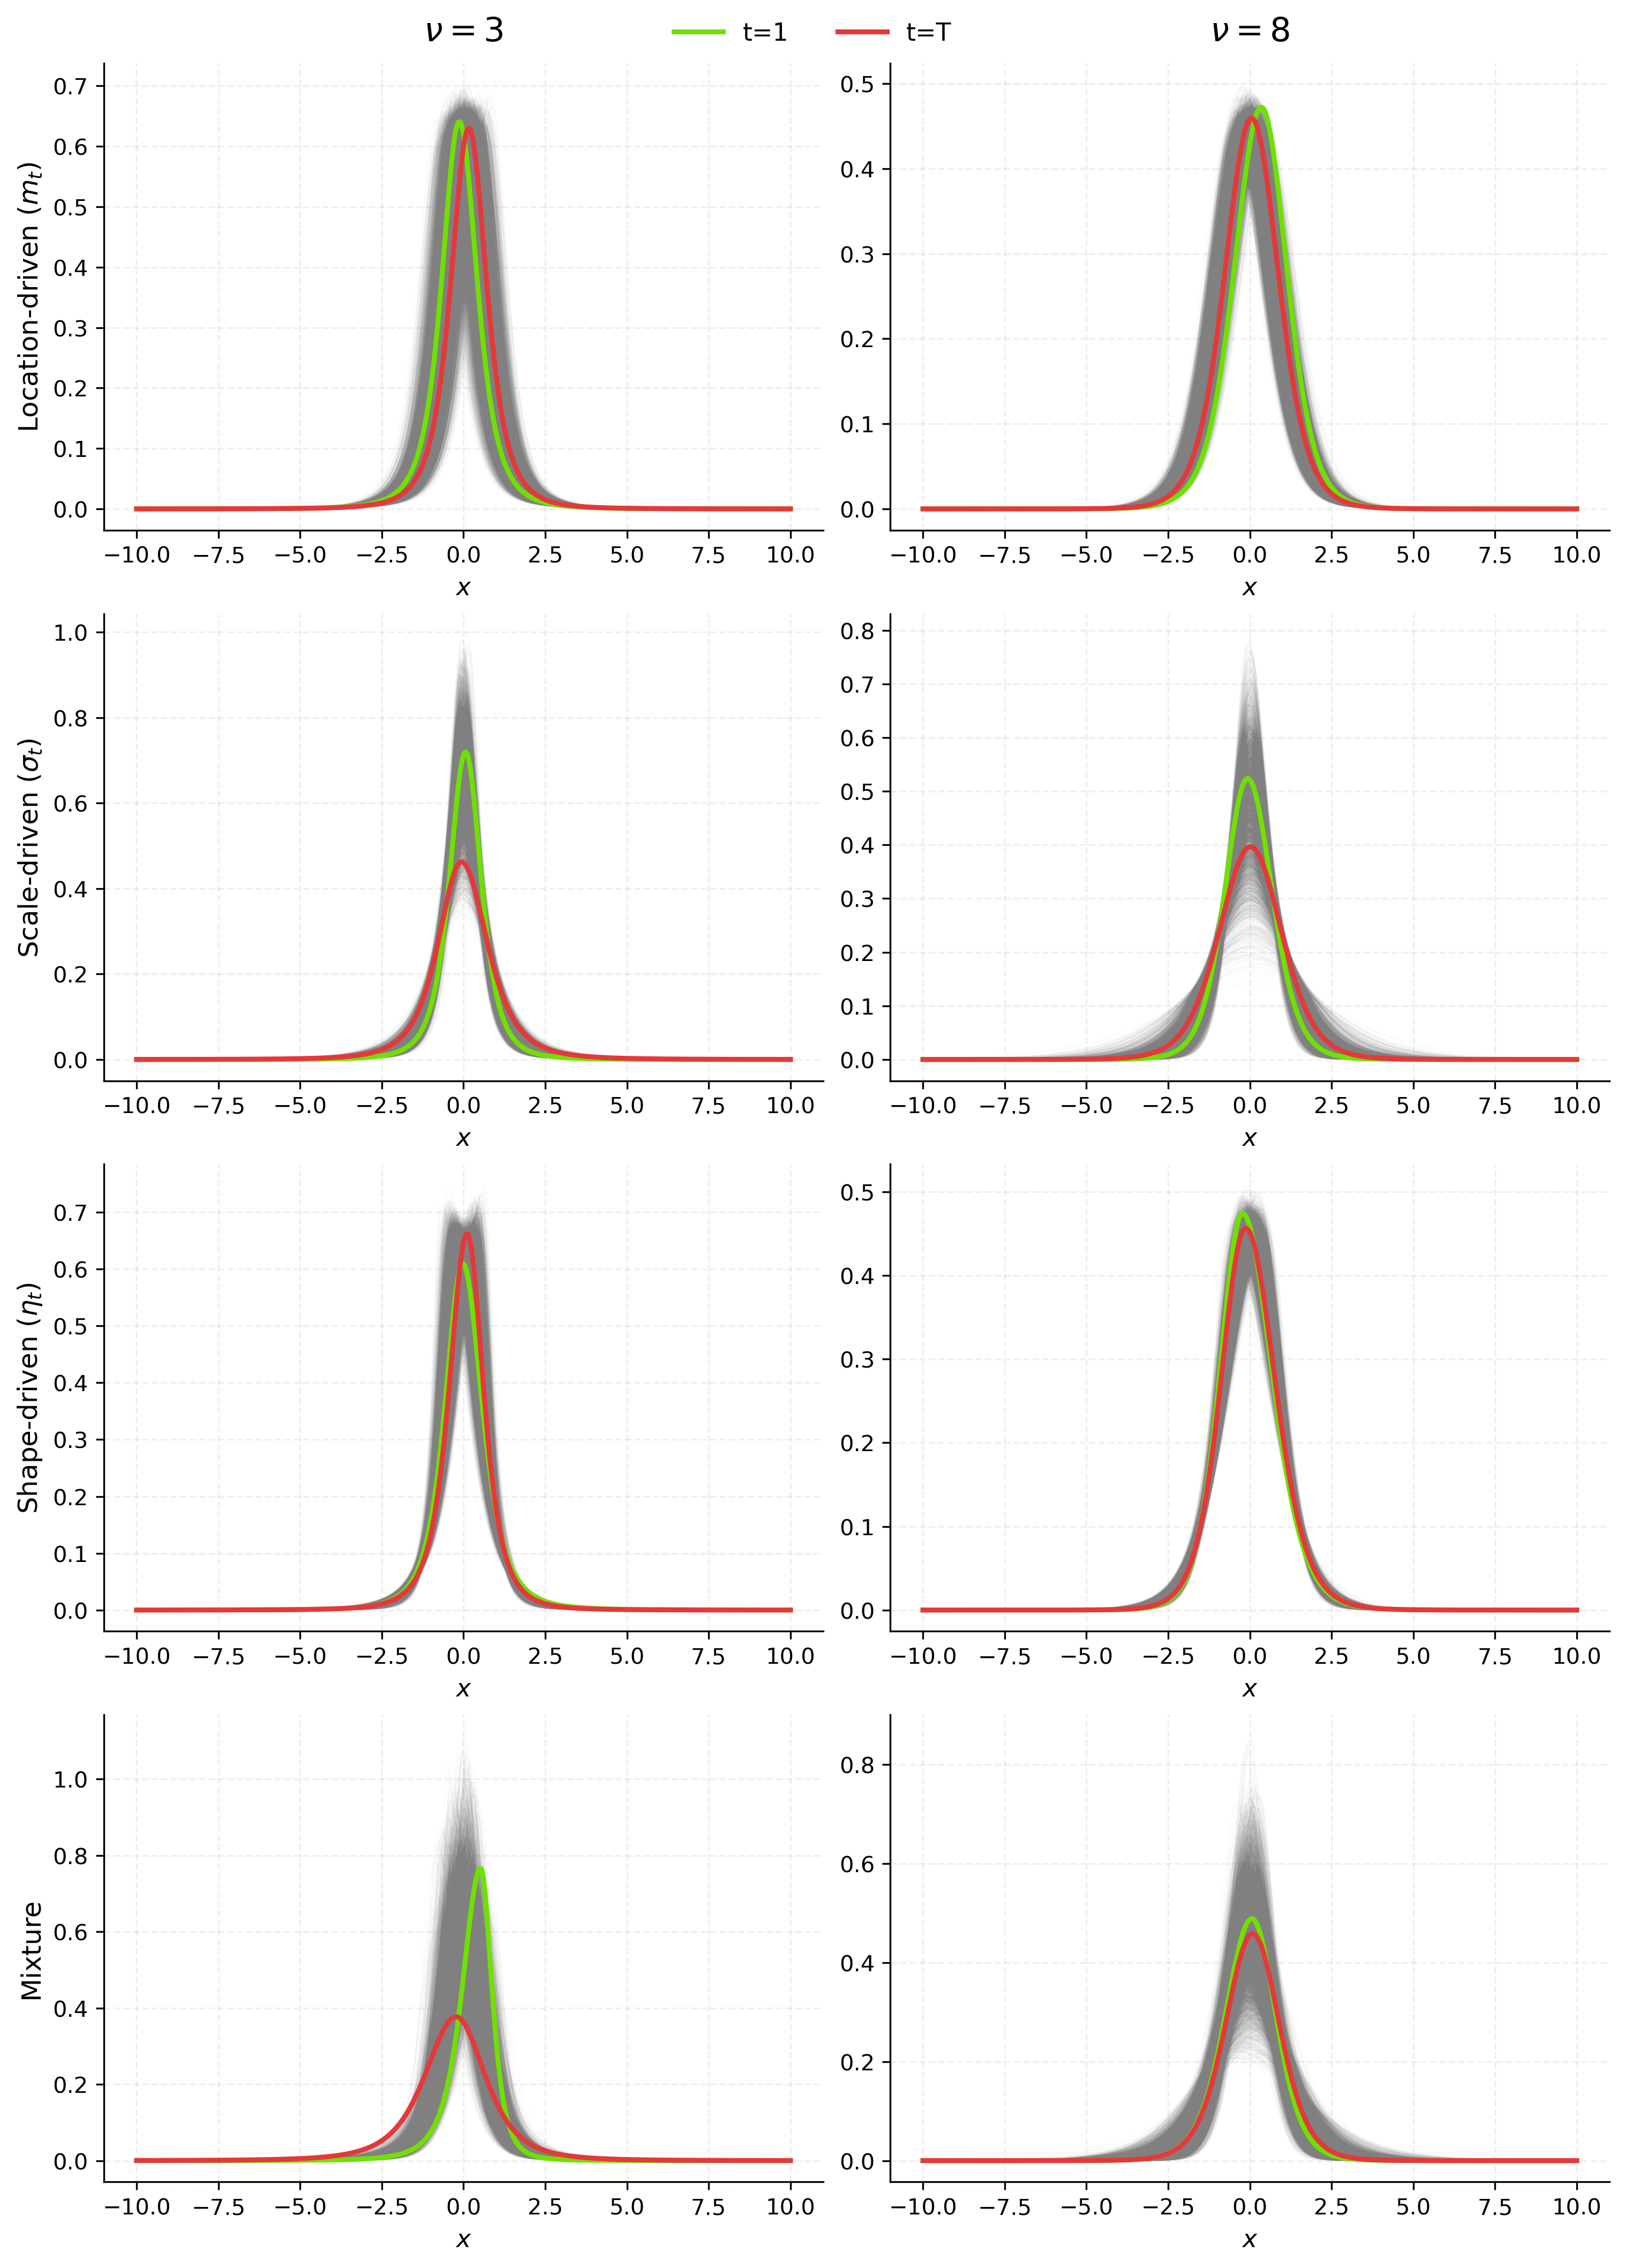

In [7]:
# Plotting simulations
doc_path = "../../densities4risk_doc/Figures/"
# ==========================================
# Metadata
# ==========================================

nus = distribution_params["nu"]
scenario_names = list(gas_params.keys())

# ==========================================
# Figure
# ==========================================

n_rows = len(scenario_names)
n_cols = len(nus)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 3.5 * n_rows),
    dpi=300,
    constrained_layout=True,
    squeeze=False
)

# ==========================================
# Plot loop
# ==========================================

for i, scenario in enumerate(scenario_names):

    for j, nu in enumerate(nus):

        ax = axes[i, j]

        key = f"{scenario}___nu={nu}"

        data = sim_database[key]["replications"][0]["densities"]

        # ----------------------------------
        # Background densities
        # ----------------------------------

        data.plot(
            color="gray",
            alpha=0.03,
            linewidth=0.5,
            legend=False,
            ax=ax
        )

        # ----------------------------------
        # First curve
        # ----------------------------------

        first_line = data.iloc[:, 0].plot(
            color="#70e000",
            linewidth=2.2,
            ax=ax,
            label="t=1"
        )

        # ----------------------------------
        # Last curve
        # ----------------------------------

        last_line = data.iloc[:, -1].plot(
            color="#e5383b",
            linewidth=2.2,
            ax=ax,
            label="t=T"
        )

        # ==================================
        # Titles / labels
        # ==================================

        if i == 0:
            ax.set_title(
                rf"$\nu={nu}$",
                fontsize=15,
                fontweight="bold",
                pad=10
            )

        if j == 0:
            ax.set_ylabel(
                gas_params[scenario]["Description"],
                # scenario.replace("_", " ").title() + "\nDensity",
                fontsize=12
            )

        ax.set_xlabel(r"$x$", fontsize=11)

        # ==================================
        # Styling
        # ==================================

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.grid(
            True,
            linestyle="--",
            alpha=0.2
        )

# ==========================================
# Shared legend
# ==========================================

handles = [
    axes[0, 0].lines[-2],
    axes[0, 0].lines[-1]
]

labels = ["t=1", "t=T"]

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=False,
    fontsize=11
)

plt.savefig(''.join([doc_path, "sinape_gasSim_all.png"]), bbox_inches='tight') # PDFs are better for LaTeX
plt.show()

# KDE

In [8]:
rot_grid = {
    "method": ["rot"], #rot/2, 2*rot
    "kernel": ["gaussian"],
    "sigma_robust": [False]
}

# adaptive_grid = {
#     "method": ["adaptive"], 
#     "kernel": ["gaussian"]
# }

# t_dfs = [3]
# adaptive_grid_t = {
#     "method": ["adaptive"], 
#     "kernel": ["t-student"],
#     "df": [df for df in t_dfs],
# }

density_param_grid = {}
for grid in [rot_grid]:
    for params in ParameterGrid(grid):
        
        key_parts = [params["kernel"]]
        if "method" in params: key_parts.append(params["method"])
        if "df" in params: key_parts.append(f"df={params['df']}")
        if params.get("sigma_robust"): key_parts.append("robust")
        if params.get("cv") == "LOO": key_parts.append("loo")
        
        full_model_name = "_".join(key_parts).replace(".", "")
        
        kernel_label = params["kernel"]
        if "df" in params:
            kernel_label += f"+df={params['df']}"
            
        bw_label = params.get("method", "fixed")
        if params.get("sigma_robust"): bw_label += "_robust"
        if params.get("cv") == "LOO": bw_label += "_loo"


        density_param_grid[full_model_name] = {
            "kernel": kernel_label,
            "bandwidth": bw_label,
            "params": params  
        }

print("KDE models:")
for name, values in density_param_grid.items():
    print("\t",name, ":", values["params"])

print(f"Total KDE models: {len(density_param_grid.items())}")

KDE models:
	 gaussian_rot : {'kernel': 'gaussian', 'method': 'rot', 'sigma_robust': False}
Total KDE models: 1


In [9]:
total = len(sim_database) * N_REPS * len(density_param_grid)
pbar = tqdm(total=total, desc="Total CV Progress")

kde_databases = {}
# progress = 0
for scenario, database in sim_database.items():
    print(f"Processing configuration for {database['params']}")
    kde_databases[scenario] = {}
    sim_reps_database = sim_database[scenario]["replications"]
    
    for n_rep, df in sim_reps_database.items():
        print(f"\t{n_rep}")
        returns_df = sim_reps_database[n_rep]['samples']
        kde_databases[scenario][n_rep] = {}
        
        for kde_bw_name, kde_bw_params in density_param_grid.items():
            print(f"\t simulation n. = {n_rep}: {kde_bw_name}")
            
            # bandwidths
            df_h = kde.df_bandwidth_selector(returns_df, **kde_bw_params["params"])    
            kde_params = {k: v for k, v in kde_bw_params["params"].items() if k in ['kernel', 'df']}
            
            # kdes
            df_grids, df_densities = kde.df_to_kde(
                X=returns_df, 
                h=df_h, 
                normalize_densities=False,
                **kde_params
            )

            bootstraps = sim_reps_database[n_rep]["bootstraps"]
            bootstraps_samples = pd.concat([bootstrap["Z_it_b"] for bootstrap in bootstraps], axis=1) 
            df_h_b = kde.df_bandwidth_selector(bootstraps_samples, **kde_bw_params["params"])    
            df_grids_b, df_densities_b = kde.df_to_kde(
                X=bootstraps_samples, 
                h=df_h_b, 
                normalize_densities=False,
                **kde_params
            )
            df_bootstrap_kdes = df_densities_b.copy()
            # df_bootstrap_kdes["Eboot_X_T"] = df_bootstrap_kdes.mean(axis=1)

            rep_result = {
                        "scenario":     scenario,
                        "n_rep":        n_rep,
                        "model_name":   kde_bw_name,
                        "kde_params":   kde_bw_params["kernel"],
                        "kernel":       kde_bw_params["params"]["kernel"],
                        "bw_params":    kde_bw_params["bandwidth"],
                        "bw_method":    kde_bw_params["params"]["method"],
                        "df_h":         df_h,
                        "df_support":   df_grids,
                        "df_densities": df_densities,
                        "bootstrap_kdes": df_bootstrap_kdes
                }

            kde_databases[scenario][n_rep][kde_bw_name] = rep_result
            
            joblib.dump(rep_result, f"{KDES_PATH}{scenario}___rep_{n_rep}___kde_{kde_bw_name}.jbl")

            del df_h
            del df_grids
            del df_densities
            del kde_params

            # progress += 1
            # print(f"{progress}/{total}")
            pbar.update(1)

Total CV Progress:   0%|          | 0/8 [00:00<?, ?it/s]

Processing configuration for {'scenario': 'scenario_1___nu=3', 'nu': 3, 'alpha': array([[0.08, 0.  , 0.  ],
       [0.  , 0.01, 0.  ],
       [0.  , 0.  , 0.01]]), 'beta': array([[0.9 , 0.  , 0.  ],
       [0.  , 0.95, 0.  ],
       [0.  , 0.  , 0.95]])}
	0
	 simulation n. = 0: gaussian_rot
Processing configuration for {'scenario': 'scenario_1___nu=8', 'nu': 8, 'alpha': array([[0.08, 0.  , 0.  ],
       [0.  , 0.01, 0.  ],
       [0.  , 0.  , 0.01]]), 'beta': array([[0.9 , 0.  , 0.  ],
       [0.  , 0.95, 0.  ],
       [0.  , 0.  , 0.95]])}
	0
	 simulation n. = 0: gaussian_rot
Processing configuration for {'scenario': 'scenario_2___nu=3', 'nu': 3, 'alpha': array([[0.01, 0.  , 0.  ],
       [0.  , 0.08, 0.  ],
       [0.  , 0.  , 0.01]]), 'beta': array([[0.95, 0.  , 0.  ],
       [0.  , 0.9 , 0.  ],
       [0.  , 0.  , 0.95]])}
	0
	 simulation n. = 0: gaussian_rot
Processing configuration for {'scenario': 'scenario_2___nu=8', 'nu': 8, 'alpha': array([[0.01, 0.  , 0.  ],
       [0.  , 0.

In [10]:
# kdes_paths = [''.join([CV_FILES_PATH, x]) for x in os.listdir(CV_FILES_PATH) if "scenario" in x]
kde_jbls_path = KDES_PATH
kdes_paths = [''.join([kde_jbls_path, x]) for x in os.listdir(kde_jbls_path)]

kde_addresses = []
for path_name in kdes_paths:
    obj = joblib.load(path_name)
    kde_address = {
        "scenario":   obj["scenario"],
        "n_rep":      obj["n_rep"],
        "model_name": obj["model_name"],
        "address":    path_name
    }
    kde_addresses.append(kde_address)

kde_addresses = sorted(
    kde_addresses,
    key=lambda x: (x["scenario"], x["n_rep"], x["model_name"])
)

kde_index = {
    (d["scenario"], d["n_rep"], d["model_name"]): d["address"]
    for d in kde_addresses
}

# $Y_t=\Lambda(\hat{f_t})$

In [11]:
n_kde_addresses = len(kde_addresses)
pbar = tqdm(total=n_kde_addresses, desc="Total LQD(fhat) Progress")

for kde in kde_addresses:
    scenario_kde_dict = joblib.load(kde["address"])
    id_scenario_kde     = scenario_kde_dict["scenario"]
    n_rep               = scenario_kde_dict["n_rep"]
    model_name_path     = scenario_kde_dict['model_name']
    model_name          = scenario_kde_dict['model_name'].replace("_", " ")

    mlqdt = lqdt.mLQDT()
    model_lqd = mlqdt.transform(
        densities=scenario_kde_dict["df_densities"],
        densities_supports=scenario_kde_dict["df_support"], 
        verbose=False
        )
    # model_lqd.densities_to_lqdensities(verbose=False)
    
    # 2. L2 Expansion (K_dFPC)
    Y_t  = model_lqd.lqd.copy()
    Y_t.index = model_lqd.lqd_support

    bootstrap_kdes      = scenario_kde_dict["bootstrap_kdes"]
    bootstrap_kdes.columns = scenario_kde_dict["df_densities"].columns[-N_BOOT:]
    bootstrap_kdes_supports = bootstrap_kdes.copy()
    bootstrap_kdes_supports.loc[:,:] = bootstrap_kdes_supports.index.to_numpy()[:, None]
    bootstrap_kdes_supports.columns = scenario_kde_dict["df_densities"].columns[-N_BOOT:]
    mlqdt_boot = lqdt.mLQDT()
    model_lqd_boot = mlqdt_boot.transform(
        densities=bootstrap_kdes,
        densities_supports=bootstrap_kdes_supports, 
        verbose=False
        )
    Y_t_boot  = model_lqd_boot.lqd.copy()
    Y_t_boot.index = model_lqd_boot.lqd_support
    Eboot_X_T = Y_t_boot.mean(axis=1).to_frame()
    Eboot_X_T.columns = [Y_t.columns[-1]]
    Eboot_X_T_support = Eboot_X_T.copy()
    Eboot_X_T_support = Eboot_X_T_support.index.to_numpy()[:, None]

    kde_mlqdt_result = {
                "scenario":     kde["scenario"],
                "n_rep":        kde["n_rep"],
                "model_name":   kde["model_name"],
                "kde_mlqdt":    Y_t,
                "kde_mlqdt_boot": Y_t_boot,
                "Eboot_X_T":    Eboot_X_T,
                "Eboot_X_T_support": Eboot_X_T_support
                
        }
    
    joblib.dump(kde_mlqdt_result, f"{KDES_LQDS_PATH}lqd___scenario_{id_scenario_kde}___rep_{n_rep}___kde_{model_name_path}.jbl")

    pbar.update(1)

Total LQD(fhat) Progress:   0%|          | 0/8 [00:00<?, ?it/s]

/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: overflow encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:504: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: overflow encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:504: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: overflow encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, N

In [12]:
# kdes_lqd_paths = [''.join([KDE_LQD_PATH, x]) for x in os.listdir(KDE_LQD_PATH) if "scenario" in x]
kdes_lqd_paths = [''.join([KDES_LQDS_PATH, x]) for x in os.listdir(KDES_LQDS_PATH)]


kdes_lqd_addresses = []
for path_name in kdes_lqd_paths:
    obj = joblib.load(path_name)
    kde_address = {
        "scenario":   obj["scenario"],
        "n_rep":      obj["n_rep"],
        "model_name": obj["model_name"],
        "address":    path_name
    }
    kdes_lqd_addresses.append(kde_address)

kde_lqd_index = {
    (d["scenario"], d["n_rep"], d["model_name"]): d["address"]
    for d in kdes_lqd_addresses
}

# Cross-validation

In [13]:
# 1. Setup Logger
logger = logging.getLogger("Density_Estimation")
logger.setLevel(logging.DEBUG)

# 2. Setup File Handler
file_handler = logging.FileHandler(LOG_PATH)
file_handler.setFormatter(logging.Formatter('%(asctime)s | %(levelname)s | %(message)s'))
logger.addHandler(file_handler)

# 3. CAPTURE WARNINGS: This handles "Forecast with mean" style warnings
logging.captureWarnings(True)

In [14]:
KdFPC_kwargs = {
    "p": 5,
    # "select_ncomp": "variance",
    "dimension": 3
}

In [ ]:
initial_window = T-1
horizon = 1

total_models = len(kde_addresses)
pbar = tqdm(total=total_models, desc="Total CV Progress")

logger.info("\nInitiating cross validation...")
for kde_address in kde_addresses:
    print(kde_address)
    scenario_kde_dict = joblib.load(kde_address["address"])

    # KDE database
    id_scenario_kde     = scenario_kde_dict["scenario"]
    sim_info            = sim_database[id_scenario_kde]["params"]
    n_rep               = scenario_kde_dict["n_rep"]
    model_name_path     = scenario_kde_dict['model_name']
    model_name          = scenario_kde_dict['model_name'].replace("_", " ")
    logger.info(
            f"Scenario: {id_scenario_kde} | n_rep: {n_rep} | KDE model: {model_name}"
            )

    df_support, df_densities = scenario_kde_dict["df_support"], scenario_kde_dict["df_densities"]

    # Simulations database
    sim_densities         = sim_database[id_scenario_kde]["replications"][n_rep]["densities"]
    sim_densities_supp    = sim_densities.copy()
    sim_densities_supp.loc[:,:] = sim_densities_supp.index.to_numpy()[:, None]


    # L2 database
    kde_lqd_address       = kde_lqd_index.get((id_scenario_kde, n_rep, scenario_kde_dict['model_name']))
    scenario_mlqdt        = joblib.load(kde_lqd_address)
    scenario_kde_lqd      = scenario_mlqdt["kde_mlqdt"]
    scenario_kde_lqd_supp = scenario_kde_lqd.copy()
    scenario_kde_lqd_supp.loc[:,:] = scenario_kde_lqd_supp.index.to_numpy()[:, None]
    
    # Cross-validation
    windows = cv.cv_window(T=df_densities.shape[1], h=horizon, window_type="rolling", window_size=300)
    measures = []
    for fold, window in enumerate(windows):
            fold += 1
            print(f"\t\t>>> cv {fold}/{len(windows)}")
            idx_train      = window[0]
            idx_test       = window[1]
            test_date      = df_densities.columns[idx_test]
            
            #------------ target variables ------------#
            Y_t_support, Y_t                   = scenario_kde_lqd_supp.loc[:, test_date], scenario_kde_lqd.loc[:, test_date]
            # lambda(f_{n+1})
            Eboot_X_T_support, Eboot_X_T = scenario_mlqdt["Eboot_X_T_support"], scenario_mlqdt["Eboot_X_T"]
            f_hat_t_supp, f_hat_t = df_support.loc[:, test_date], df_densities.loc[:, test_date]
            f_t_support,  f_t     = sim_densities_supp.loc[:, test_date], sim_densities.loc[:, test_date]
            # lambda^{-1}(X_boot)
            #-----------------------------------------#

            # Train-test split
            kde_train_support, kde_train = df_support.iloc[:,idx_train], df_densities.iloc[:,idx_train]
            
            # Forecasting
            forecaster = fp.DensityForecaster(kdfpc_kwargs=KdFPC_kwargs, maxlags=5)
            forecaster.fit(kde_train, kde_train_support)
            mdfpc_fc = forecaster.predict(horizon=1, var_lags=1, forecast_index=test_date)

            # Predictions
            Y_hat_t = mdfpc_fc["future_L2_curves"]

            lambda_inv_Y_hat_t_supp=  mdfpc_fc["future_supports"]
            lambda_inv_Y_hat_t =      mdfpc_fc["future_densities"]

            #------------ common grid ------------#
            # \hat{Y}_{n+1} x  Y_{n+1}
            acc_measures = acc.overall_measures(forecast=Y_hat_t, test=Y_t)
            temp_df = pd.DataFrame({
                    "support":  Y_t.index,
                    "actual":   Y_t.iloc[:, 0].values,
                    "forecast": Y_hat_t.iloc[:, 0].values,
                    "date":     test_date[0],
                    "fold":     fold
                    }).set_index(["fold", "date", "support"])
            measures.append({
                    "scenario":   id_scenario_kde,
                    "n_rep":      n_rep,
                    "model_name": model_name,
                    "fold":       fold,
                    "comparison": "yHatFc_Y",
                    "fc_date":    test_date[0],
                    **acc_measures,
                    "curves":     temp_df
            })
            # \hat{Y}_{n+1} x  Xboot
            acc_measures = acc.overall_measures(forecast=Y_hat_t, test=Eboot_X_T)
            temp_df = pd.DataFrame({
                    "support":  Eboot_X_T.index,
                    "actual":   Eboot_X_T.iloc[:, 0].values,
                    "forecast": Y_hat_t.iloc[:, 0].values,
                    "date":     test_date[0],
                    "fold":     fold
                    }).set_index(["fold", "date", "support"])
            measures.append({
                    "scenario":   id_scenario_kde,
                    "n_rep":      n_rep,
                    "model_name": model_name,
                    "fold":       fold,
                    "comparison": "yHatFc_Xboot",
                    "fc_date":    test_date[0],
                    **acc_measures,
                    "curves":     temp_df
            })
            # \Lambda^{-1}(\hat{Y}_{n+1}) x  \hat{f}_{n+1}
            df_supp, df_kde, df_fc = fdaUtils.align_densities(
                                            f_hat_t_supp, 
                                            f_hat_t, 
                                            lambda_inv_Y_hat_t_supp, 
                                            lambda_inv_Y_hat_t, 
                                            lambda_inv_Y_hat_t.columns
                                            )
            acc_measures = acc.overall_measures(forecast=df_fc, test=df_kde)
            temp_df = pd.DataFrame({
                    "support":  df_supp.iloc[:,0].values,
                    "actual":   df_kde.iloc[:, 0].values,
                    "forecast": df_fc.iloc[:, 0].values,
                    "date":     test_date[0],
                    "fold":     fold
                    }).set_index(["fold", "date", "support"])
            measures.append({
                    "scenario":   id_scenario_kde,
                    "n_rep":      n_rep,
                    "model_name": model_name,
                    "fold":       fold,
                    "comparison": "fHatFc_fHat",
                    "fc_date":    test_date[0],
                    **acc_measures,
                    "curves":     temp_df
            })
            # \Lambda^{-1}(\hat{Y}_{n+1}) x  f_{n+1}
            df_supp, df_kde, df_fc = fdaUtils.align_densities(
                                            f_t_support, 
                                            f_t, 
                                            lambda_inv_Y_hat_t_supp, 
                                            lambda_inv_Y_hat_t, 
                                            lambda_inv_Y_hat_t.columns
                                            )
            acc_measures = acc.overall_measures(forecast=df_fc, test=df_kde)
            temp_df = pd.DataFrame({
                    "support":  df_supp.iloc[:,0].values,
                    "actual":   df_kde.iloc[:, 0].values,
                    "forecast": df_fc.iloc[:, 0].values,
                    "date":     test_date[0],
                    "fold":     fold
                    }).set_index(["fold", "date", "support"])
            measures.append({
                    "scenario":   id_scenario_kde,
                    "n_rep":      n_rep,
                    "model_name": model_name,
                    "fold": fold,
                    "comparison": "fHatFc_f",
                    "fc_date":    test_date[0],
                    **acc_measures,
                    "curves":     temp_df
            })
    joblib.dump(measures, f"{CV_FCS_PATH}cvFc___scenario_{id_scenario_kde}___rep_{n_rep}___kde_{model_name_path}.jbl")
    pbar.update(1)

Total CV Progress:   0%|          | 0/8 [00:00<?, ?it/s]

{'scenario': 'scenario_1___nu=3', 'n_rep': 0, 'model_name': 'gaussian_rot', 'address': '../data/interim/simulation/20260524/02_kdes/scenario_1___nu=3___rep_0___kde_gaussian_rot.jbl'}
		>>> cv 1/5000
		>>> cv 2/5000
		>>> cv 3/5000
		>>> cv 4/5000
		>>> cv 5/5000
		>>> cv 6/5000
		>>> cv 7/5000
		>>> cv 8/5000
		>>> cv 9/5000
		>>> cv 10/5000
		>>> cv 11/5000
		>>> cv 12/5000
		>>> cv 13/5000
		>>> cv 14/5000
		>>> cv 15/5000
		>>> cv 16/5000
		>>> cv 17/5000
		>>> cv 18/5000
		>>> cv 19/5000
		>>> cv 20/5000
		>>> cv 21/5000
		>>> cv 22/5000
		>>> cv 23/5000
		>>> cv 24/5000
		>>> cv 25/5000
		>>> cv 26/5000
		>>> cv 27/5000
		>>> cv 28/5000
		>>> cv 29/5000
		>>> cv 30/5000
		>>> cv 31/5000
		>>> cv 32/5000
		>>> cv 33/5000
		>>> cv 34/5000
		>>> cv 35/5000
		>>> cv 36/5000
		>>> cv 37/5000
		>>> cv 38/5000
		>>> cv 39/5000
		>>> cv 40/5000
		>>> cv 41/5000
		>>> cv 42/5000
		>>> cv 43/5000
		>>> cv 44/5000
		>>> cv 45/5000
		>>> cv 46/5000
		>>> cv 47/5000
		>>> cv 48/5000
		>>> cv 4